First, we load the dataset to ensure it is accessible for analysis.


In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
df= kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "abrerjawod/student-mental-health-and-burnout-dataset",
    "Social_media_impact_on_life.csv"
)
df.head()

/tmp/ipykernel_10398/3490190219.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df= kagglehub.load_dataset(


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


Now that the dataset is available, we will explore potential relationships between social media usage, sleep duration, and academic and mental health indicators in students.

<Axes: xlabel='Age', ylabel='Avg_Daily_Usage_Hours'>

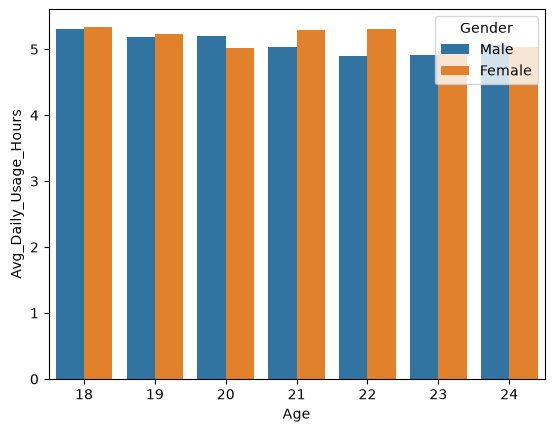

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df,x="Age", y="Avg_Daily_Usage_Hours",errorbar=None,hue="Gender")

Across ages 18 to 24, average daily usage appears relatively stable, with no clear upward or downward trend observed in the data. Next, we will quantify relationships between variables by examining correlations among numerical features such as age, daily usage, sleep duration, and mental health score.

Text(0.5, 1.0, 'Correlation across different categories')

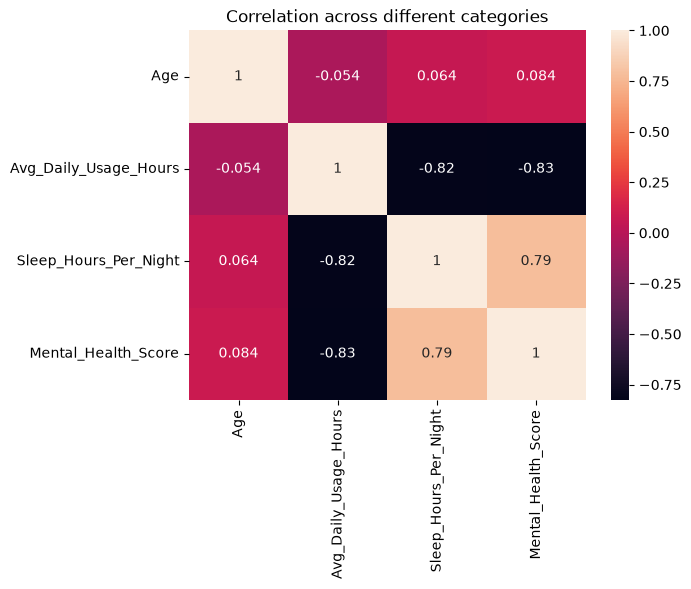

In [70]:
sns.heatmap(df.drop(columns="Student_ID").corr(numeric_only=True),annot=True)
plt.title("Correlation across different categories")


A strong positive correlation is observed between sleep duration and mental health score, suggesting that students who sleep more hours per night generally report better mental health. We will now return to platform usage and identify which platforms are reported most frequently overall.


In [7]:
df["Most_Used_Platform"].value_counts()

Most_Used_Platform
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
KakaoTalk     12
VKontakte     12
Name: count, dtype: int64

Instagram, TikTok, and Facebook are the most frequently reported platforms in the dataset, with all other platforms showing substantially lower usage counts. Based on this distribution, the next step is to analyze user characteristics within these three platforms to identify potential differences across demographic and behavioral variables.


Text(0.5, 1.0, 'Academic Levels by Sleep Hours and Daily Phone Usage')

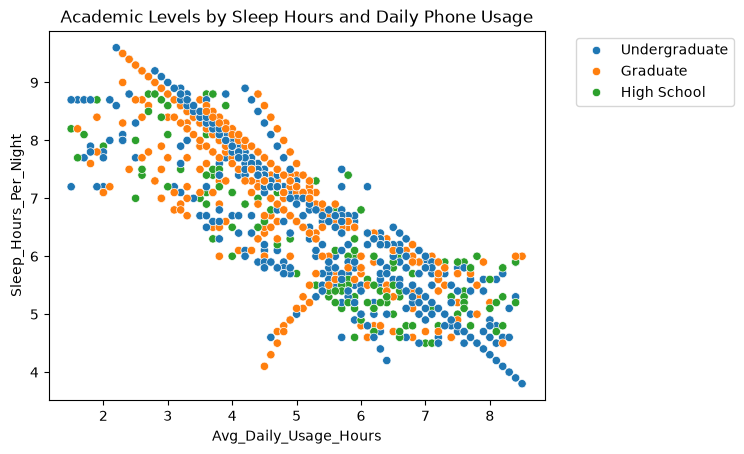

In [74]:
top_three = ["Facebook", "Instagram", "TikTok"]
filtered_df = df[df["Most_Used_Platform"].isin(top_three)]
sns.scatterplot(
    data=filtered_df,
    x="Avg_Daily_Usage_Hours",
    y="Sleep_Hours_Per_Night",
    hue="Academic_Level"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Academic Levels by Sleep Hours and Daily Phone Usage")


A noticeable pattern emerges in which high school students appear more frequently among higher usage levels and lower sleep durations compared to other academic levels. To better understand whether this pattern extends to wellbeing outcomes, we will next examine mental health scores across academic levels.


Text(0.5, 1.0, 'Mental Health by Academic Levels by Gender')

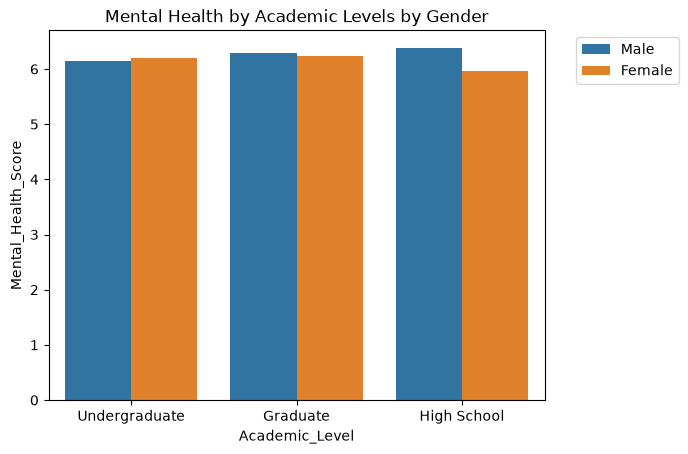

In [9]:
sns.barplot(data=df,x="Academic_Level",y="Mental_Health_Score",errorbar=None,hue="Gender")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Mental Health by Academic Levels by Gender")

Overall, mental health scores remain relatively consistent across education levels, clustering around a value of approximately six. One exception is female high school students, who show a slightly lower average score compared to the other groups. To understand this difference more clearly, we will examine this subgroup in more detail.

Text(0.5, 1.0, 'High School Boys and Girls Sleeping hours vs Avg Daily Phone Usage')

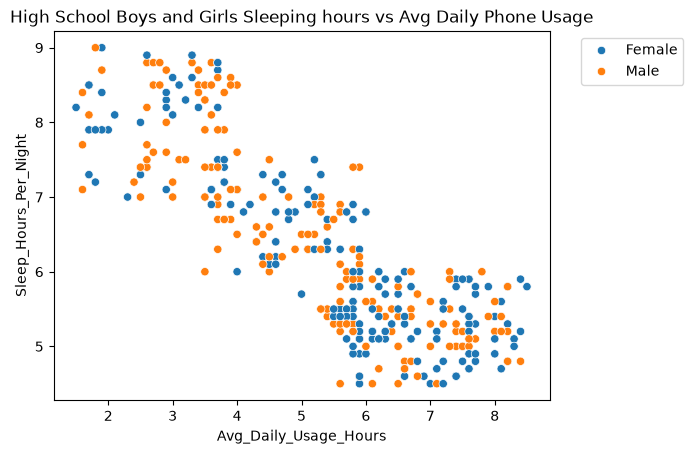

In [10]:
high_school=df["Academic_Level"]=="High School"
sns.scatterplot(data=df[high_school],x="Avg_Daily_Usage_Hours",y="Sleep_Hours_Per_Night",hue="Gender")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("High School Boys and Girls Sleeping hours vs Avg Daily Phone Usage")

The distribution between both genders appears relatively similar in terms of average daily usage and sleep hours. This suggests that usage time alone may not explain the differences observed in mental health scores. To investigate further, we will break the analysis down by specific subgroups and platform usage patterns.

In [11]:
high_school_students=df[high_school]
girls=high_school_students["Gender"]=="Female"
boys=high_school_students["Gender"]=="Male"
high_school_girls=high_school_students[girls]
high_school_boys=high_school_students[boys]





In [17]:
high_school_girls["Most_Used_Platform"].value_counts()

Most_Used_Platform
Instagram    34
YouTube      32
Facebook     25
TikTok       22
Snapchat     21
LinkedIn     20
Twitter      18
Name: count, dtype: int64

In [18]:
high_school_boys["Most_Used_Platform"].value_counts()

Most_Used_Platform
LinkedIn     33
TikTok       30
Snapchat     30
YouTube      26
Instagram    25
Facebook     21
Twitter      15
Name: count, dtype: int64

After examining platform distribution within each gender group, LinkedIn appears more frequently among boys, while Instagram appears more frequently among girls in terms of raw counts within the high school subset.

To further refine this analysis, the next step is to evaluate average daily usage hours per platform within each group in order to assess whether these differences reflect intensity of use rather than simple frequency counts.

In [ ]:
round(high_school_girls.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()/high_school_students.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()*100,2)

Most_Used_Platform
Facebook     54.71
Instagram    63.77
LinkedIn     37.65
Snapchat     44.51
TikTok       43.56
Twitter      47.62
YouTube      58.83
Name: Avg_Daily_Usage_Hours, dtype: float64

In [15]:
round(high_school_boys.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()/high_school_students.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].sum()*100,2)

Most_Used_Platform
Facebook     45.29
Instagram    36.23
LinkedIn     62.35
Snapchat     55.49
TikTok       56.44
Twitter      52.38
YouTube      41.17
Name: Avg_Daily_Usage_Hours, dtype: float64

Among high school students, Instagram accounts for 63.77% of total usage hours from girls and 36.23% from boys. This reflects how total platform usage is distributed within each group.

For LinkedIn, the pattern is reversed: boys contribute 62.35% of total usage hours, while girls account for 37.65%.

These results show clear differences in how total usage is distributed across platforms by gender within the high school subgroup. Next, we examine whether these differences are associated with variations in sleep duration between groups.

In [61]:
round((high_school_girls["Sleep_Hours_Per_Night"].mean()/high_school_students["Sleep_Hours_Per_Night"].mean()*100)-100,0)

np.float64(-2.0)

In [60]:
round((high_school_boys["Sleep_Hours_Per_Night"].mean()/high_school_students["Sleep_Hours_Per_Night"].mean()*100)-100,0)

np.float64(2.0)

To assess whether the observed differences in platform usage are reflected in sleep patterns, we compare average sleep duration between genders relative to the overall high school mean.

The results show a very small deviation from the subgroup average: boys report approximately +2% higher sleep duration, while girls report approximately −2% lower sleep duration compared to the overall high school mean.

Given the minimal magnitude of these differences, sleep duration appears to be largely consistent between genders within the high school subgroup. This suggests that the previously observed differences in platform usage are not strongly associated with meaningful variations in sleep duration.

To further investigate potential drivers of these patterns, the next step will be to analyze sleep distribution across individual platforms.

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
Age,1.000000,0.028820,0.073234,0.060183
Avg_Daily_Usage_Hours,0.028820,1.000000,-0.835255,-0.830279
Sleep_Hours_Per_Night,0.073234,-0.835255,1.000000,0.863599
Mental_Health_Score,0.060183,-0.830279,0.863599,1.000000


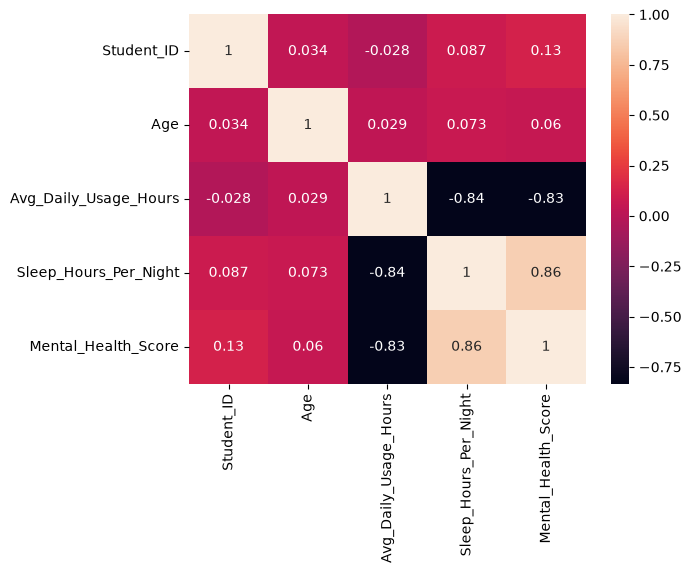

In [66]:
sns.heatmap(high_school_students.corr(numeric_only=True),annot=True)
high_school_students.drop(columns="Student_ID").corr(numeric_only=True)

To quantify the relationships between numerical variables, we compute the correlation matrix for the high school subgroup.

The results show a very strong negative correlation between average daily usage and sleep duration (r = -0.84), indicating that higher levels of social media usage are strongly associated with lower reported sleep hours.

Similarly, average daily usage is also strongly negatively correlated with mental health score (r = -0.83), suggesting that higher usage levels are associated with lower mental health outcomes within this subgroup.

In contrast, sleep duration shows a strong positive correlation with mental health score (r = 0.86), indicating that students who sleep more tend to report better mental health outcomes.

Overall, the high school subgroup reveals a consistent pattern: increased social media usage is associated with reduced sleep, which in turn is associated with lower mental health scores.

Conclusion

This analysis explored the relationship between social media usage, sleep duration, academic level, and mental health indicators among students.

Across both the full dataset and the high school subgroup, consistent patterns were observed. Average daily social media usage shows a strong negative correlation with sleep duration (r ≈ -0.82) and mental health score (r ≈ -0.83). In contrast, sleep duration is strongly positively correlated with mental health score (r ≈ 0.79–0.86 depending on the subset). These relationships remain stable across different subsets of the data, indicating that the observed patterns are not limited to a specific demographic group.

Platform-level and gender-based analyses provided additional context but did not significantly alter the overall pattern, suggesting that the primary relationships are driven more by overall usage intensity than by specific platforms or demographic categories.

These findings may offer a possible explanation for the slightly lower mental health scores observed among female high school students compared to their male counterparts, as females in this subgroup show higher engagement on certain high-usage platforms. However, this should be interpreted cautiously, as the analysis does not control for confounding variables and does not establish causation.